In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Evaluating Model: KNN
  Run 1: Acc=0.8687, Features=24
  Features selected: [ 1  2  4  5  6  9 10 11 14 18 19 21 22 24 26 27 28 30 31 32 33 34 36 37]
  Run 2: Acc=0.8586, Features=14
  Features selected: [ 0  2  3  5  8 13 15 16 18 24 27 30 32 33]
  Run 3: Acc=0.8687, Features=16
  Features selected: [ 0  2  5 10 11 12 15 16 21 22 26 27 29 32 33 35]
  Run 4: Acc=0.8687, Features=20
  Features selected: [ 2  3  4  5  6 10 12 15 16 18 20 22 24 26 27 29 31 32 35 37]
  Run 5: Acc=0.8788, Features=17
  Features selected: [ 3  4  6  7 13 16 17 18 19 20 21 23 24 25 27 28 37]
  Run 6: Acc=0.8788, Features=19
  Features selected: [ 0  3  4  5  9 10 11 12 14 15 18 19 20 22 27 28 32 33 34]
  Run 7: Acc=0.8687, Features=19
  Features selected: [ 0  2  4  7  9 10 12 14 15 17 20 22 25 27 29 30 33 34 37]
  Run 8: Acc=0.8889, Features=17
  Features selected: [ 2  4  7  8  9 13 14 17 18 19 20 21 23 29 33 34 37]
  Run 9: Acc=0.8687, Features=23
  Features selected: [ 0  3  4  7  8  9 11 12 13 16 19 20 

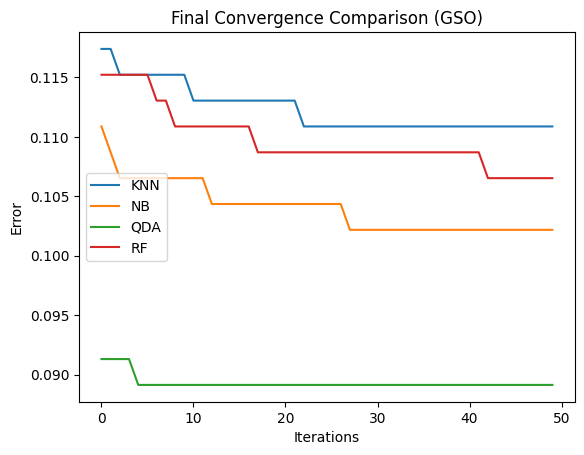


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 85.35%
Precision : 0.1515
Recall    : 0.0769
F1-Score  : 0.0938

Avg Execution Time : 11.6372 s
Avg Memory Used    : 0.1262 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.07%   0.5333  0.0846 0.1443      19.0    50.00%
   NB  83.03%   0.3112  0.2385 0.2694      17.7    53.42%
  QDA  85.76%   0.3000  0.0846 0.1316      20.1    47.11%
   RF  85.76%   0.2583  0.0385 0.0652      18.4    51.58%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-CM1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7734, Features=12
  Features selected: [ 0  2  3  4  8  9 10 11 15 16 17 20]
  Run 2: Acc=0.7687, Features=14
  Features selected: [ 0  1  3  4  5  6  7  9 10 11 12 14 16 19]
  Run 3: Acc=0.7610, Features=13
  Features selected: [ 0  1  3  6  7  8  9 12 13 14 17 19 21]
  Run 4: Acc=0.7563, Features=11
  Features selected: [ 0  1  4  5  7  8 11 13 16 19 21]
  Run 5: Acc=0.7627, Features=11
  Features selected: [ 0  1  3  5  6  9 12 13 14 15 18]
  Run 6: Acc=0.7585, Features=14
  Features selected: [ 0  2  4  5  6  7 10 11 14 16 17 18 19 20]
  Run 7: Acc=0.7589, Features=14
  Features selected: [ 0  1  2  4  5  6  7 10 11 12 14 18 19 21]
  Run 8: Acc=0.7627, Features=12
  Features selected: [ 0  2  3  6  9 10 11 12 14 17 19 21]
  Run 9: Acc=0.7610, Features=15
  Features selected: [ 0  1  2  4  5  7  8 12 13 14 15 16 17 18 20]
  Run 10: Acc=0.7567, Features=12
  Features selected: [ 0  1  2  4  7  8 11 12 13 14 15 19]
  Accuracy without FS: 76.66%

E

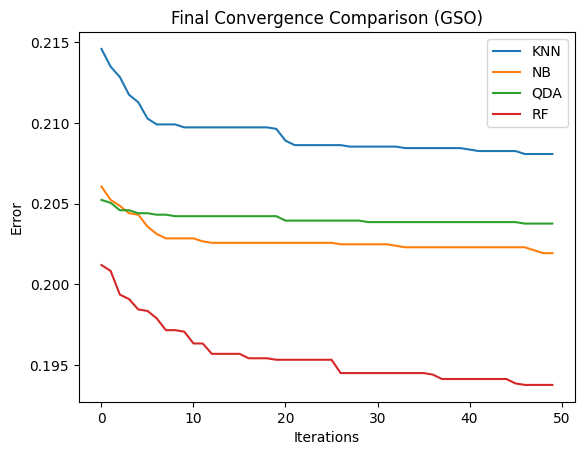


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 78.12%
Precision : 0.4941
Recall    : 0.1479
F1-Score  : 0.2201

Avg Execution Time : 39.4960 s
Avg Memory Used    : 1.1881 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  76.20%   0.3759  0.1604 0.2247      12.8    41.82%
   NB  77.89%   0.4566  0.1488 0.2239       8.8    60.00%
  QDA  78.86%   0.6206  0.0434 0.0811      11.3    48.64%
   RF  78.11%   0.4777  0.1855 0.2668      11.9    45.91%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-JM1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.6986, Features=12
  Features selected: [ 0  1  4  5  6  8  9 14 15 19 20 21]
  Run 2: Acc=0.7239, Features=12
  Features selected: [ 1  3  4  5  8  9 11 12 14 17 18 19]
  Run 3: Acc=0.7211, Features=8
  Features selected: [ 1  3  6  8  9 13 17 21]
  Run 4: Acc=0.7155, Features=11
  Features selected: [ 0  1  3  7  8 11 13 17 18 20 21]
  Run 5: Acc=0.6704, Features=10
  Features selected: [ 0  1  3  4  6 13 14 17 18 19]
  Run 6: Acc=0.7296, Features=13
  Features selected: [ 2  3  5  6  8  9 12 14 15 16 18 20 21]
  Run 7: Acc=0.7014, Features=17
  Features selected: [ 0  1  2  4  6  7  8 11 12 13 14 15 16 17 18 19 20]
  Run 8: Acc=0.7296, Features=11
  Features selected: [ 1  2  3  4  6  9 11 16 18 19 21]
  Run 9: Acc=0.7324, Features=8
  Features selected: [ 2  6  8  9 11 16 19 21]
  Run 10: Acc=0.7099, Features=11
  Features selected: [ 0  4  5  7 11 12 13 16 17 19 20]
  Accuracy without FS: 69.86%

Evaluating Model: NB
  Run 1: Acc=0.7268, Featur

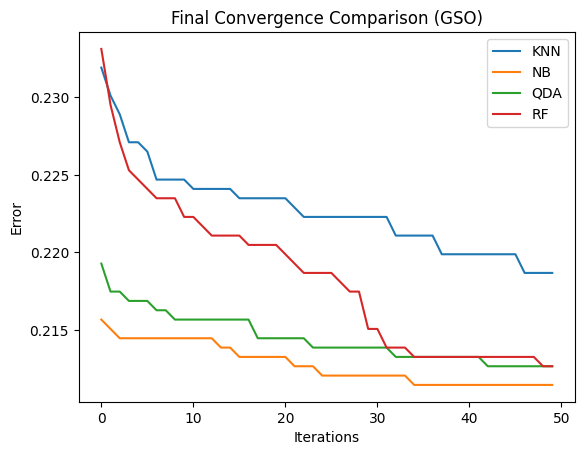


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 72.54%
Precision : 0.4697
Recall    : 0.2181
F1-Score  : 0.2953

Avg Execution Time : 12.7380 s
Avg Memory Used    : -0.0623 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  71.32%   0.4124  0.2021 0.2705      11.3    48.64%
   NB  72.82%   0.4736  0.2362 0.3149       9.9    55.00%
  QDA  74.11%   0.5342  0.1777 0.2664      12.7    42.27%
   RF  72.28%   0.4577  0.2489 0.3221      11.0    50.00%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-KC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7627, Features=22
  Features selected: [ 0  1  2  3  4  5  6  9 10 12 16 18 24 26 27 28 30 32 34 35 38 39]
  Run 2: Acc=0.7966, Features=22
  Features selected: [ 0  2  3  5  7  9 10 12 15 16 19 20 23 25 27 28 29 30 31 33 34 37]
  Run 3: Acc=0.7966, Features=17
  Features selected: [ 0  3  5  6 15 23 25 26 27 28 29 30 31 32 34 37 38]
  Run 4: Acc=0.7797, Features=21
  Features selected: [ 1  2  3  4  5  6  8 12 13 14 20 21 22 24 25 27 29 32 34 36 39]
  Run 5: Acc=0.7797, Features=19
  Features selected: [ 0  4  5  7  9 11 12 14 18 23 27 28 30 32 33 35 36 37 39]
  Run 6: Acc=0.7627, Features=19
  Features selected: [ 1  4  5  8 10 11 15 19 20 21 22 23 24 25 26 28 29 34 38]
  Run 7: Acc=0.7966, Features=21
  Features selected: [ 0  3  4  5  6  7 10 12 14 15 21 22 24 25 26 27 28 30 31 35 39]
  Run 8: Acc=0.7797, Features=25
  Features selected: [ 1  4  5  6  7  8 10 12 13 14 15 16 23 24 25 27 29 30 31 32 33 34 35 36
 37]
  Run 9: Acc=0.7119, Features=

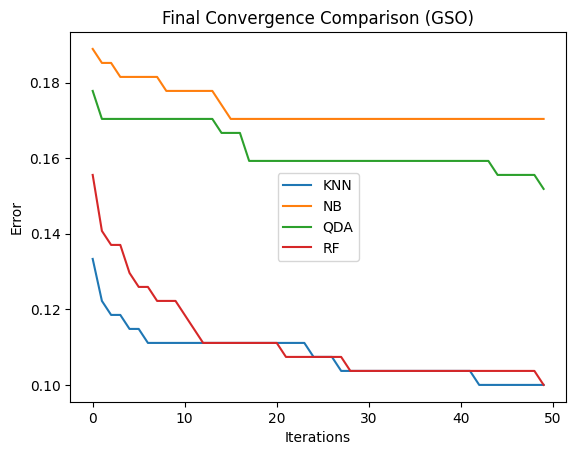


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 77.97%
Precision : 0.1562
Recall    : 0.0909
F1-Score  : 0.1123

Avg Execution Time : 9.5196 s
Avg Memory Used    : 0.0031 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  77.29%   0.1242  0.0455 0.0649      20.2    49.50%
   NB  78.81%   0.3771  0.2000 0.2606      17.3    56.75%
  QDA  79.49%   0.3750  0.1545 0.2171      19.8    50.50%
   RF  78.14%   0.1683  0.0727 0.0995      21.2    47.00%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-KC3.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9732, Features=20
  Features selected: [ 3  5  7  9 10 11 12 13 17 21 23 24 25 26 27 28 32 34 35 37]
  Run 2: Acc=0.9732, Features=20
  Features selected: [ 2  3  4  5  8  9 13 15 17 18 24 25 26 28 30 31 32 33 34 36]
  Run 3: Acc=0.9749, Features=24
  Features selected: [ 1  2  3  4  5 10 12 13 17 18 21 22 23 24 26 30 31 32 33 34 35 36 37 38]
  Run 4: Acc=0.9749, Features=24
  Features selected: [ 1  3  4  5  6  8 10 13 16 17 18 21 22 23 25 26 27 28 29 31 32 34 35 36]
  Run 5: Acc=0.9749, Features=22
  Features selected: [ 2  4  5  6  7  8  9 12 13 17 19 20 21 22 24 25 26 28 31 33 37 38]
  Run 6: Acc=0.9698, Features=14
  Features selected: [ 2  5  6  9 11 12 13 15 22 23 29 32 33 38]
  Run 7: Acc=0.9732, Features=23
  Features selected: [ 1  2  3  6  8 10 12 13 14 15 16 20 22 24 25 26 28 29 31 32 35 37 38]
  Run 8: Acc=0.9749, Features=16
  Features selected: [ 1  4  5  6 11 13 14 20 21 23 27 30 31 32 35 36]
  Run 9: Acc=0.9765, Features=16
  Featu

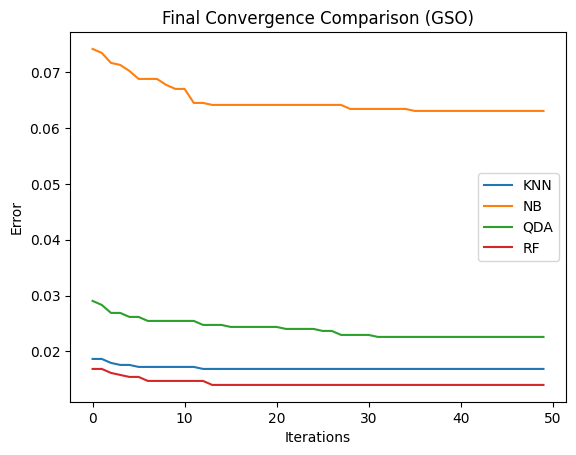


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 95.73%
Precision : 0.1044
Recall    : 0.0893
F1-Score  : 0.0846

Avg Execution Time : 13.3095 s
Avg Memory Used    : -0.0863 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.39%   0.3000  0.0714 0.1140      19.8    49.23%
   NB  93.82%   0.0399  0.0643 0.0476      16.4    57.95%
  QDA  96.10%   0.0091  0.0071 0.0080      23.1    40.77%
   RF  97.17%   0.2871  0.1357 0.1810      18.1    53.59%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.5263, Features=13
  Features selected: [ 0  2  8  9 11 15 16 20 21 25 28 33 34]
  Run 2: Acc=0.6053, Features=23
  Features selected: [ 2  5  8  9 13 15 17 20 21 22 24 26 27 28 29 30 31 32 33 34 35 38 39]
  Run 3: Acc=0.7105, Features=19
  Features selected: [ 0  6  7  8 13 14 17 18 20 21 23 24 26 27 29 32 33 34 36]
  Run 4: Acc=0.6579, Features=19
  Features selected: [ 0  2  3  8  9 13 17 20 21 22 23 24 26 27 31 32 34 35 39]
  Run 5: Acc=0.5526, Features=20
  Features selected: [ 5  6 13 15 16 17 20 21 22 24 25 26 27 28 30 32 33 36 37 38]
  Run 6: Acc=0.6842, Features=20
  Features selected: [ 1  2  5  8 10 12 13 14 15 17 19 20 23 24 25 26 30 33 34 37]
  Run 7: Acc=0.6316, Features=20
  Features selected: [ 0  1  2  6  7  9 12 13 15 16 17 18 21 22 25 26 28 33 35 39]
  Run 8: Acc=0.6316, Features=20
  Features selected: [ 1  3  5  7  9 14 15 19 20 21 22 24 25 26 28 29 33 34 35 38]
  Run 9: Acc=0.6842, Features=22
  Features selected: [ 1  2  5  6 

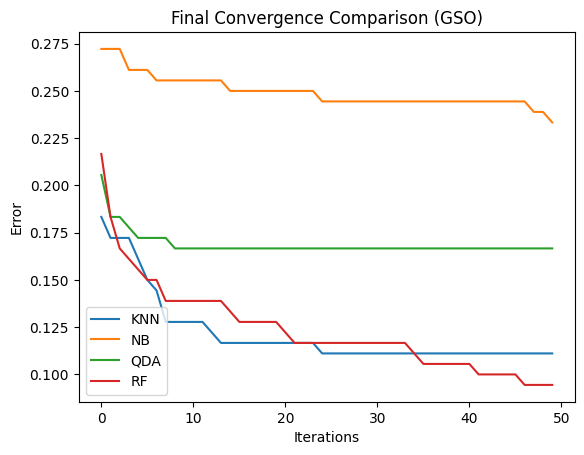


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 70.39%
Precision : 0.6528
Recall    : 0.3269
F1-Score  : 0.4214

Avg Execution Time : 9.1856 s
Avg Memory Used    : 0.0025 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  62.89%   0.4531  0.3692 0.4052      19.5    51.25%
   NB  73.16%   0.7286  0.3846 0.4973      16.5    58.75%
  QDA  69.47%   0.5813  0.4000 0.4722      21.0    47.50%
   RF  58.68%   0.3867  0.3154 0.3420      22.3    44.25%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MC2.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8816, Features=24
  Features selected: [ 0  1  4  6  7  8  9 11 12 14 15 16 21 22 23 25 29 30 31 32 33 34 35 37]
  Run 2: Acc=0.8684, Features=22
  Features selected: [ 0  2  5  6  7  8 10 12 19 20 22 24 25 27 29 30 32 33 34 35 36 37]
  Run 3: Acc=0.8684, Features=21
  Features selected: [ 2  4  6  7  9 12 14 16 18 21 22 23 25 26 28 30 31 33 35 36 37]
  Run 4: Acc=0.8421, Features=14
  Features selected: [ 6  8  9 11 12 13 14 16 22 25 26 28 30 33]
  Run 5: Acc=0.8421, Features=22
  Features selected: [ 1  7  8 10 11 13 14 15 16 18 19 20 21 26 27 28 29 30 31 33 35 36]
  Run 6: Acc=0.8684, Features=18
  Features selected: [ 0  1  2  4  6  7 11 12 13 14 16 19 22 24 28 29 33 37]
  Run 7: Acc=0.8816, Features=17
  Features selected: [ 1  4  6  9 11 12 13 14 19 21 22 25 26 27 28 31 33]
  Run 8: Acc=0.8421, Features=16
  Features selected: [ 7  9 12 15 16 18 20 21 22 24 26 27 29 30 32 37]
  Run 9: Acc=0.8816, Features=17
  Features selected: [ 1  9 12 15 

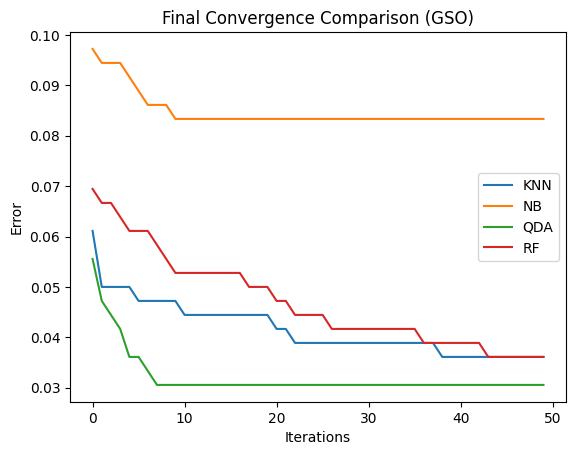


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 83.88%
Precision : 0.1964
Recall    : 0.2812
F1-Score  : 0.2185

Avg Execution Time : 9.8250 s
Avg Memory Used    : 0.0026 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  86.45%   0.3652  0.4000 0.3779      18.2    52.11%
   NB  80.00%   0.2929  0.6250 0.3982      16.7    56.05%
  QDA  87.89%   0.4524  0.5875 0.5079      13.9    63.42%
   RF  86.71%   0.3399  0.2375 0.2695      18.7    50.79%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MW1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9104, Features=17
  Features selected: [ 2  3  4  5  6  7  9 10 11 13 16 19 23 24 30 31 37]
  Run 2: Acc=0.9104, Features=17
  Features selected: [ 0  2  3  4  6  7 13 14 16 20 23 24 27 28 31 33 37]
  Run 3: Acc=0.8962, Features=24
  Features selected: [ 0  1  2  4  6  8  9 11 12 13 15 18 19 20 21 22 23 27 28 29 30 32 33 37]
  Run 4: Acc=0.9009, Features=21
  Features selected: [ 1  3  5  6  8  9 13 15 16 17 18 19 21 22 24 26 27 30 32 35 37]
  Run 5: Acc=0.9151, Features=13
  Features selected: [ 1  4  5  8  9 11 13 16 18 19 20 22 36]
  Run 6: Acc=0.9057, Features=18
  Features selected: [ 0  6  7 11 12 18 19 21 22 23 28 29 30 31 32 35 36 37]
  Run 7: Acc=0.8962, Features=21
  Features selected: [ 2  3  4  6  7  8 10 14 16 18 20 22 24 25 28 30 32 33 34 35 37]
  Run 8: Acc=0.8962, Features=22
  Features selected: [ 0  2  3  4  7  8  9 10 11 16 17 18 19 21 22 24 28 30 31 33 36 37]
  Run 9: Acc=0.8915, Features=23
  Features selected: [ 1  2  3  5  6 

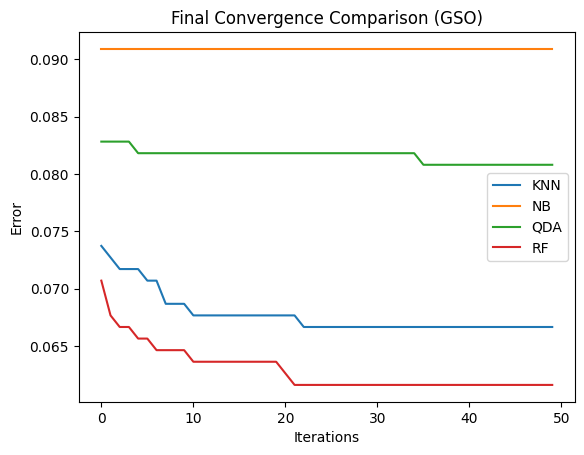


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 90.45%
Precision : 0.3125
Recall    : 0.1389
F1-Score  : 0.1709

Avg Execution Time : 10.7635 s
Avg Memory Used    : 0.0035 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  90.33%   0.2629  0.1167 0.1535      20.1    47.11%
   NB  90.28%   0.4037  0.2944 0.3381      19.1    49.74%
  QDA  91.42%   0.4932  0.1500 0.2260      20.6    45.79%
   RF  92.17%   0.6156  0.1833 0.2781      17.3    54.47%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9777, Features=17
  Features selected: [ 1  5  6  9 11 15 16 17 19 20 24 25 27 28 31 32 33]
  Run 2: Acc=0.9777, Features=26
  Features selected: [ 1  2  5  6  7  8  9 10 11 12 15 16 17 18 19 20 22 24 28 29 30 31 32 33
 34 35]
  Run 3: Acc=0.9777, Features=21
  Features selected: [ 0  1  3  5  9 10 11 13 15 16 18 19 20 22 23 27 28 29 33 34 35]
  Run 4: Acc=0.9777, Features=15
  Features selected: [ 0  2  3  4  5 15 19 20 22 26 28 29 30 35 36]
  Run 5: Acc=0.9732, Features=23
  Features selected: [ 1  2  3  5  7  9 11 12 13 15 16 20 23 24 26 27 28 29 30 31 33 35 36]
  Run 6: Acc=0.9777, Features=17
  Features selected: [ 0  1  2  4  8 10 12 19 20 21 22 26 27 30 32 34 36]
  Run 7: Acc=0.9777, Features=17
  Features selected: [ 4  6  7  8 11 12 15 17 18 21 22 24 26 28 30 32 34]
  Run 8: Acc=0.9777, Features=19
  Features selected: [ 0  4  5  8  9 10 11 12 14 16 17 19 20 21 23 30 32 33 36]
  Run 9: Acc=0.9777, Features=19
  Features selected: [ 3  4  5

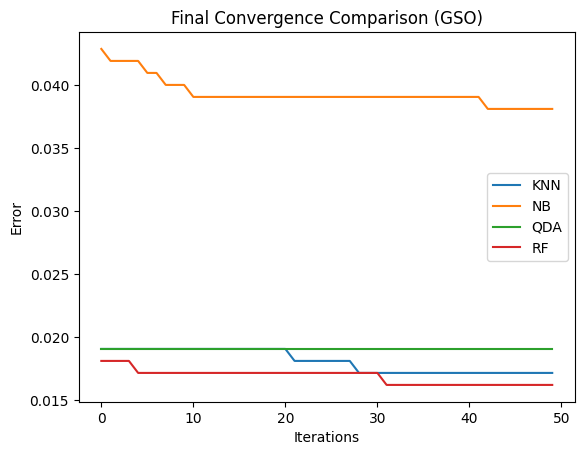


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 96.21%
Precision : 0.0167
Recall    : 0.0500
F1-Score  : 0.0250

Avg Execution Time : 10.3967 s
Avg Memory Used    : 0.0033 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.72%   0.0000  0.0000 0.0000      19.5    47.30%
   NB  94.60%   0.1454  0.2000 0.1518      14.9    59.73%
  QDA  97.77%   0.0000  0.0000 0.0000      18.0    51.35%
   RF  97.68%   0.0000  0.0000 0.0000      18.7    49.46%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC2.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8704, Features=20
  Features selected: [ 2  4  6  7  8 11 15 17 19 23 24 25 26 28 29 30 32 33 36 37]
  Run 2: Acc=0.8704, Features=20
  Features selected: [ 1  3  4  8  9 11 12 15 17 19 20 24 25 26 27 28 29 30 32 37]
  Run 3: Acc=0.8796, Features=19
  Features selected: [ 0  1  4  6  7  8 10 13 14 16 19 20 22 25 27 28 29 33 35]
  Run 4: Acc=0.8735, Features=16
  Features selected: [ 0  3  6  8 10 15 16 19 26 28 30 32 33 34 36 37]
  Run 5: Acc=0.8889, Features=19
  Features selected: [ 4  7  8 13 14 19 20 22 23 25 26 27 28 29 30 33 35 36 37]
  Run 6: Acc=0.8549, Features=18
  Features selected: [ 1  2  8 10 11 13 15 16 17 18 21 23 24 25 30 31 33 36]
  Run 7: Acc=0.8611, Features=17
  Features selected: [ 0  3  6  7 10 13 15 19 20 23 24 26 28 30 32 34 36]
  Run 8: Acc=0.8796, Features=18
  Features selected: [ 0  1  4  7  8  9 10 13 14 18 19 20 22 25 29 33 35 37]
  Run 9: Acc=0.8796, Features=16
  Features selected: [ 5  6 14 16 19 21 22 23 26 27 30 

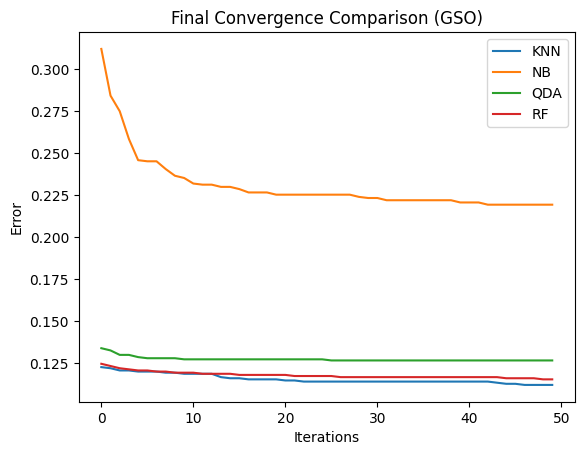


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 72.99%
Precision : 0.4249
Recall    : 0.3938
F1-Score  : 0.2637

Avg Execution Time : 12.4698 s
Avg Memory Used    : 0.0057 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.28%   0.4627  0.1175 0.1826      18.1    52.37%
   NB  82.62%   0.3576  0.4875 0.4068      11.7    69.21%
  QDA  87.47%   0.3571  0.0725 0.1144      16.1    57.63%
   RF  87.44%   0.4643  0.0925 0.1527      17.9    52.89%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC3.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8760, Features=23
  Features selected: [ 2  3  4  7  8 10 11 13 14 16 17 20 21 23 24 25 28 29 30 31 32 36 37]
  Run 2: Acc=0.8553, Features=17
  Features selected: [ 2  5  6  7 10 11 13 14 16 18 21 22 23 26 30 35 36]
  Run 3: Acc=0.8682, Features=15
  Features selected: [ 2  4  8 10 11 12 15 16 18 21 29 30 31 35 37]
  Run 4: Acc=0.8630, Features=18
  Features selected: [ 2  3  4  6  8  9 11 13 14 18 22 23 24 28 29 32 33 35]
  Run 5: Acc=0.8734, Features=15
  Features selected: [ 2  4  8 12 18 20 21 23 25 27 28 30 31 32 34]
  Run 6: Acc=0.8682, Features=12
  Features selected: [ 3  4  6 11 12 13 17 23 28 29 30 37]
  Run 7: Acc=0.8708, Features=20
  Features selected: [ 1  2  3  4  5  7 10 11 15 16 17 18 21 22 24 25 26 27 32 36]
  Run 8: Acc=0.8605, Features=21
  Features selected: [ 2  4  6  7  8  9 13 14 17 18 19 22 23 25 26 29 30 32 34 36 37]
  Run 9: Acc=0.8424, Features=13
  Features selected: [ 4 11 12 13 15 17 18 19 21 27 32 35 37]
  Run 10: A

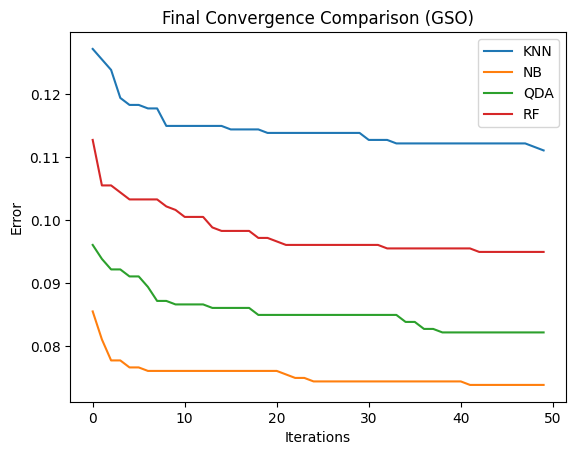


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 87.79%
Precision : 0.5937
Recall    : 0.3491
F1-Score  : 0.4394

Avg Execution Time : 12.7663 s
Avg Memory Used    : 0.0051 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  86.43%   0.5101  0.2604 0.3430      17.3    54.47%
   NB  85.94%   0.4689  0.3226 0.3776      21.3    43.95%
  QDA  88.68%   0.6963  0.3094 0.4248      20.9    45.00%
   RF  89.28%   0.6961  0.3849 0.4914      19.1    49.74%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC4.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7451, Features=15
  Features selected: [ 1  5  7  8 13 14 15 17 18 19 22 25 27 35 38]
  Run 2: Acc=0.7471, Features=17
  Features selected: [ 2  9 10 13 17 18 20 22 26 27 28 29 30 32 33 35 36]
  Run 3: Acc=0.7335, Features=22
  Features selected: [ 1  2  5  6  7 13 14 15 17 18 19 20 21 23 24 27 28 29 30 33 35 38]
  Run 4: Acc=0.7393, Features=20
  Features selected: [ 2  4  5  6  9 13 14 15 17 18 21 22 23 24 25 26 31 32 35 36]
  Run 5: Acc=0.7529, Features=15
  Features selected: [ 2  4  5  6  8  9 11 13 16 18 20 25 28 33 36]
  Run 6: Acc=0.7335, Features=21
  Features selected: [ 1  4  8 10 14 17 18 19 20 23 24 25 26 29 30 31 32 33 34 35 38]
  Run 7: Acc=0.7665, Features=20
  Features selected: [ 1  4  5  6  7  9 10 12 14 15 17 18 20 21 24 26 28 30 32 34]
  Run 8: Acc=0.7237, Features=21
  Features selected: [ 1  2  4  7  8  9 10 12 14 15 17 18 19 22 23 24 25 31 33 34 35]
  Run 9: Acc=0.7335, Features=18
  Features selected: [ 0  1  2  4  5  6  7 

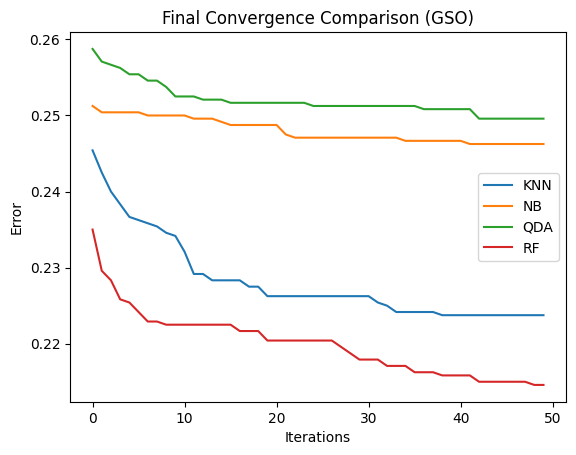


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 75.00%
Precision : 0.5859
Recall    : 0.2908
F1-Score  : 0.3778

Avg Execution Time : 14.7797 s
Avg Memory Used    : 0.0184 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  74.12%   0.5388  0.3993 0.4577      18.8    51.79%
   NB  74.01%   0.5665  0.2234 0.3200      18.7    52.05%
  QDA  73.48%   0.5588  0.1603 0.2489      20.5    47.44%
   RF  76.60%   0.6148  0.3965 0.4815      19.3    50.51%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
import warnings

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# MODEL SELECTOR
# =========================
def model_name(model_type):
    if model_type == "KNN":
        return KNeighborsClassifier()
    elif model_type == "NB":
        return GaussianNB()
    elif model_type == "QDA":
        return QuadraticDiscriminantAnalysis(reg_param=0.01)
    elif model_type == "RF":
        return RandomForestClassifier(n_estimators=20, n_jobs=-1)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC5.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

# =========================
# PREPROCESSING
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

feat = np.array(X_train_scaled)
label = np.array(y_train)

test_feat = np.array(X_test_scaled)
test_label = np.array(y_test)

# =========================
# SIGMOID + BINARISE
# =========================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binarise(position):
    prob = sigmoid(position)
    return (np.random.rand(*position.shape) < prob).astype(int)

# =========================
# FITNESS
# =========================
def fitness(selected_indices, model_type):
    if len(selected_indices) == 0:
        return 1.0

    X_tr, X_val, y_tr, y_val = train_test_split(
        feat[:, selected_indices],
        label,
        test_size=0.2,
        random_state=42,
        stratify=label
    )

    clf = model_name(model_type)
    try:
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        return float(np.sum(preds != y_val)) / len(y_val)
    except:
        return 1.0

# =========================
# LEVY FLIGHT
# =========================
def levy_flight(dimensions, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2.0)
    den = math.gamma((1 + beta) / 2.0) * beta * (2.0 ** ((beta - 1.0) / 2.0))
    sigma = (num / den) ** (1.0 / beta)
    u = np.random.randn(dimensions) * sigma
    v = np.random.randn(dimensions)
    return u / (np.abs(v) ** (1.0 / beta))

# =========================
# GSO
# =========================
def GSO(sol_count, dimensions, iterations_count, lower_bound, upper_bound, model_type):
    positions = lower_bound + np.random.rand(sol_count, dimensions) * (upper_bound - lower_bound)
    fit_vals = np.zeros(sol_count)
    bin_pop = np.zeros_like(positions, dtype=int)

    for s in range(sol_count):
        bin_pop[s] = binarise(positions[s])
        fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

    idx = np.argsort(fit_vals)
    positions = positions[idx]
    bin_pop = bin_pop[idx]
    fit_vals = fit_vals[idx]

    fitG = fit_vals[0]
    Xgb_bin = bin_pop[0].copy()
    Xgb_cont = positions[0].copy()
    convergence = []

    for t in range(iterations_count):
        A = 1.0 - t / iterations_count

        for s in range(sol_count):
            if random.random() < 0.3:
                L = levy_flight(dimensions)
                positions[s] = Xgb_cont + L * A * (Xgb_cont - positions[s])
            else:
                pred_idx = (s - 1) % sol_count
                positions[s] += A * random.random() * (Xgb_cont - positions[s]) + \
                                A * random.random() * (positions[pred_idx] - positions[s])

            positions[s] = np.clip(positions[s], lower_bound, upper_bound)

            bin_pop[s] = binarise(positions[s])
            fit_vals[s] = fitness(np.where(bin_pop[s] == 1)[0], model_type)

            if fit_vals[s] < fitG:
                fitG = fit_vals[s]
                Xgb_bin = bin_pop[s].copy()
                Xgb_cont = positions[s].copy()

        convergence.append(fitG)

    return convergence, Xgb_bin


# =========================
# MAIN LOOP
# =========================
models_list = ["KNN", "NB", "QDA", "RF"]

model_summaries = []
Total_time = []
Total_memory = []

model_curves = {}   # 🔥 NEW

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_type in models_list:
    model_obj = model_name(model_type)

    print(f"\nEvaluating Model: {model_type}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = GSO(10, feat.shape[1], 50, -4, 4, model_type)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        curves.append(conv)

        Sf_idx = np.where(best_sol == 1)[0]

        if len(Sf_idx) == 0:
            Sf_idx = np.array([np.random.randint(0, feat.shape[1])])

        clf = clone(model_obj)
        clf.fit(feat[:, Sf_idx], label)
        pred = clf.predict(test_feat[:, Sf_idx])

        acc_list.append(np.mean(pred == test_label))
        prec_list.append(precision_score(test_label, pred, zero_division=0))
        rec_list.append(recall_score(test_label, pred, zero_division=0))
        f1_list.append(f1_score(test_label, pred, zero_division=0))
        feat_list.append(len(Sf_idx))

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"  Features selected: {Sf_idx}")

    # 🔥 STORE MEAN CURVE
    model_curves[model_type] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat, label)
    pred_no_fs = clf_nofs.predict(test_feat)

    acc_no_fs = np.mean(pred_no_fs == test_label) * 100
    print(f"  Accuracy without FS: {acc_no_fs:.2f}%")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(test_label, pred_no_fs, zero_division=0))
    average_recall_without_FS.append(recall_score(test_label, pred_no_fs, zero_division=0))
    average_f1_without_FS.append(f1_score(test_label, pred_no_fs, zero_division=0))

    model_summaries.append({
        "Model": model_type,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })


# =========================
# 🔥 FINAL CONVERGENCE GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (GSO)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()


# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print(f"\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(average_accuracy_without_FS):.2f}%")
print(f"Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)